# CPG Product Intelligence - Report

* Data Extraction Date: July 22nd, 2026
* Source Dataset: Open Food Facts (Crowdsourced Open Dataset)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Importing Datasets
cocacola = pd.read_csv(r'datasets/coca-cola_from_dump.csv')
fairlife = pd.read_csv(r'datasets/fairlife_from_dump.csv')
fanta = pd.read_csv(r'datasets/fanta_from_dump.csv')
maaza = pd.read_csv(r'datasets/maaza_from_dump.csv')
minutemaid = pd.read_csv(r'datasets/minute maid_from_dump.csv')
schweppes = pd.read_csv(r'datasets/schweppes_from_dump.csv')
sprite = pd.read_csv(r'datasets/sprite_from_dump.csv')
topochico = pd.read_csv(r'datasets/topo chico_from_dump.csv')

## Section 1: Global Overview

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


# -------------------------------
# Common helpers
# -------------------------------

UNKNOWN = {"unknown", "nan", "none", ""}


def clean_values(series):
    """Clean categorical values and preserve unknown as a missing marker."""
    return (
        series
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )


def known_values(series):
    """Return only genuinely reported values."""
    s = clean_values(series)
    return s[~s.isin(UNKNOWN)]


def explode_values(df, column):
    """Explode comma-separated values and remove unknown/missing values."""
    temp = df[[column]].copy()

    temp[column] = (
        temp[column]
        .fillna("unknown")
        .astype(str)
        .str.split(",")
    )

    temp = temp.explode(column)

    temp[column] = (
        temp[column]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    return temp[~temp[column].isin(UNKNOWN)]


def pct(value, total):
    return value / total * 100 if total else 0


def observations(points):
    print("\nOBSERVATIONS")
    for point in points:
        print(f"• {point}")

### Brand: Coca-Cola

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

In [13]:
def total_market_presence(df, brand="Dataset"):

    total_records = len(df)

    country_data = explode_values(df, "countries_tags")
    total_markets = country_data["countries_tags"].nunique()

    result = pd.Series({
        "Catalog Records": total_records,
        "Markets": total_markets
    })

    ax = result.plot(kind="bar", figsize=(9, 5))

    plt.title(f"{brand} — Total Market Presence")
    plt.ylabel("Count")
    plt.xticks(rotation=0)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f")

    plt.tight_layout()
    plt.show()

    observations([
        f"The dataset contains {total_records:,} catalog records.",
        f"The records are associated with {total_markets:,} distinct reported markets.",
        "Market presence represents geographic coverage in the dataset, not verified sales or market share.",
        f"{df['countries_tags'].isna().sum():,} records originally had missing country information."
    ])

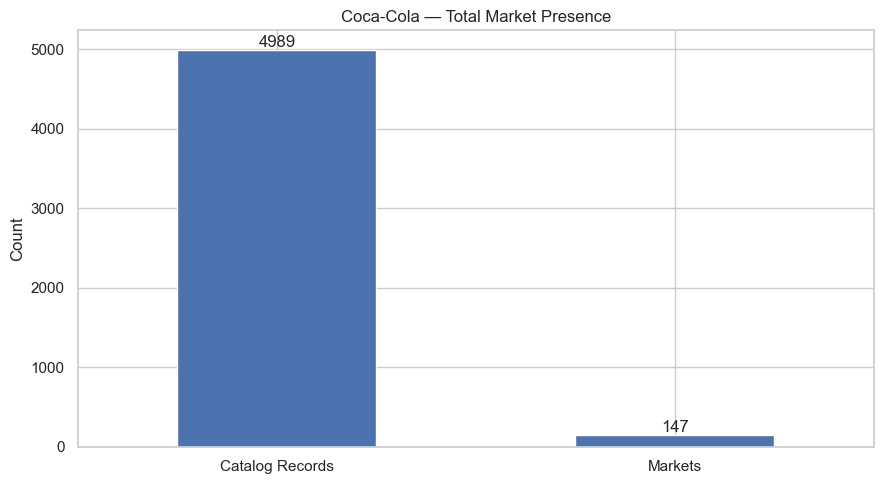


OBSERVATIONS
• The dataset contains 4,989 catalog records.
• The records are associated with 147 distinct reported markets.
• Market presence represents geographic coverage in the dataset, not verified sales or market share.
• 28 records originally had missing country information.


In [14]:
total_market_presence(cocacola, "Coca-Cola")

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

In [15]:
def market_density(df, brand="Dataset", top_n=10):

    country_data = explode_values(df, "countries_tags")

    counts = (
        country_data["countries_tags"]
        .value_counts()
        .head(top_n)
        .sort_values()
    )

    ax = counts.plot(
        kind="barh",
        figsize=(10, 6)
    )

    plt.title(f"{brand} — Market Density Distribution")
    plt.xlabel("Number of Records")
    plt.ylabel("Market")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.0f")

    plt.tight_layout()
    plt.show()

    top_market = counts.idxmax()
    top_count = counts.max()
    total_country_records = len(country_data)

    observations([
        f"{top_market.title()} has the highest catalog representation with {top_count:,} records.",
        f"The top {top_n} markets show that geographic representation is uneven.",
        f"{top_market.title()} contributes approximately {pct(top_count, total_country_records):.1f}% of all reported country associations.",
        "These counts describe dataset coverage rather than market size or sales volume."
    ])

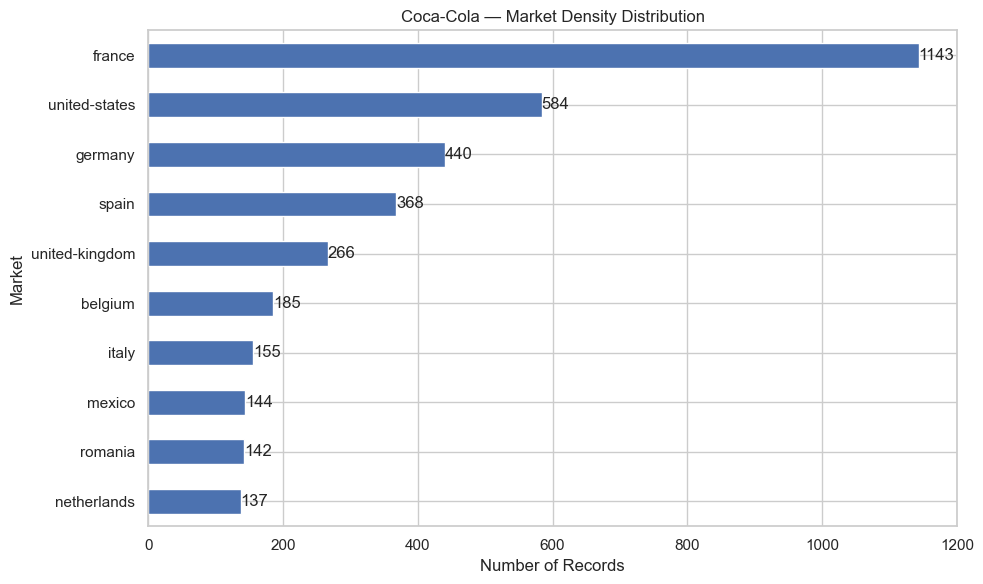


OBSERVATIONS
• France has the highest catalog representation with 1,143 records.
• The top 10 markets show that geographic representation is uneven.
• France contributes approximately 18.9% of all reported country associations.
• These counts describe dataset coverage rather than market size or sales volume.


In [16]:
market_density(cocacola, "Coca-Cola")

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Fairlife

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Fanta

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Maaza

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Minute-Maid

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Schweppes

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Sprite

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Topo Chico

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

## Section 2: Geographic Overview
Catalog Variations across Various Countries

### Brand: Coca-Cola

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Fairlife

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Fanta

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Maaza

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Minute Maid

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Schweppes

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Sprite

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Topo Chico

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

## Section 3: Health & Nutrition Differences Across Regions

### Brand: Coca-Cola

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Fairlife

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Fanta

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Maaza

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Minute Maid

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Schweppes

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Sprite

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Topo Chico

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

## Section 4: Formulation & Processing Across Regions

### Brand: Coca-Cola

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Fairlife

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Fanta

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Maaza

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Minute Maid

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Schweppes

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Sprite

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Topo Chico

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

## Section 5: Packaging Preferences Across Regions

### Brand: Coca-Cola

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Fairlife

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Fanta

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Maaza

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Minute Maid

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Schweppes

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Sprite

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Topo Chico

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

## Section 6: Limitations, Methodology & Strategic Conclusions